# Option A: Comprehensive Algorithm Comparison

Task: Implement 3 algorithms from different method families and compare them on one environment. Focus on understanding trade-offs.






# Setting up Environment

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict
import random

ENV = "MountainCar-v0"

## Inspecting Environment

In [2]:
# Environment Inspection Function
def inspect_environment(env_name):

    env = gym.make(env_name)

    print(f"\nEnvironment: {env_name}")
    print("-"*40)

    obs_space = env.observation_space
    act_space = env.action_space

    print("Observation Space:", obs_space)
    print("Action Space:", act_space)

    # Inspecting space details
    if isinstance(obs_space, gym.spaces.Discrete):
        print("Observation Type: Discrete")
        print("Number of states:", obs_space.n)

    elif isinstance(obs_space, gym.spaces.Box):
        print("Observation Type: Continuous")
        print("Shape:", obs_space.shape)
        print("Bounds:", obs_space.low, obs_space.high)

    # Getting Action space details
    if isinstance(act_space, gym.spaces.Discrete):
        print("Action Type: Discrete")
        print("Number of actions:", act_space.n)

    elif isinstance(act_space, gym.spaces.Box):
        print("Action Type: Continuous")
        print("Shape:", act_space.shape)
        print("Bounds:", act_space.low, act_space.high)

    env.close()


In [3]:
# Inspecting Environment
inspect_environment(ENV)


Environment: MountainCar-v0
----------------------------------------
Observation Space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action Space: Discrete(3)
Observation Type: Continuous
Shape: (2,)
Bounds: [-1.2  -0.07] [0.6  0.07]
Action Type: Discrete
Number of actions: 3


In [4]:
# Discretization for tabular methods
class Discretizer:
    def __init__(self, env, bins=(18, 14)):
        self.low = env.observation_space.low
        self.high = env.observation_space.high
        self.bins = bins

        self.bin_width = (self.high - self.low) / np.array(bins)

    def discretize(self, state):
        ratios = (state - self.low) / self.bin_width
        indices = np.floor(ratios).astype(int)
        return tuple(np.clip(indices, 0, np.array(self.bins) - 1))

def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

# SARSA with Tile Coding

## Tile Coding

In [5]:
class TileCoder:
    def __init__(self, low, high, tilings=8, tiles=(8, 8)):
        self.low = np.array(low)
        self.high = np.array(high)
        self.tilings = tilings
        self.tiles = np.array(tiles)

        self.dim = len(low)
        self.tile_width = (self.high - self.low) / (self.tiles - 1)

        # Offsets for each tiling
        self.offsets = np.array([
            (i / tilings) * self.tile_width
            for i in range(tilings)
        ])

        # Total tiles per tiling
        self.tiles_per_tiling = np.prod(self.tiles)

        # Total features
        self.n_features = self.tiles_per_tiling * self.tilings

    def get_features(self, state):
        state = np.array(state)
        active_tiles = []

        for tiling in range(self.tilings):
            offset = self.offsets[tiling]
            shifted = state + offset

            ratios = (shifted - self.low) / self.tile_width
            indices = np.floor(ratios).astype(int)

            # Clip indices
            indices = np.clip(indices, 0, self.tiles - 1)

            # Converting multi-dim index → flat index
            flat_index = np.ravel_multi_index(indices, self.tiles)

            # Global index across tilings
            global_index = tiling * self.tiles_per_tiling + flat_index
            active_tiles.append(global_index)

        return active_tiles # list of active tile indices (sparse representation)

## SARSA Agent

In [6]:
class SarsaAgent:
    def __init__(self, tile_coder, n_actions, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.tc = tile_coder
        self.n_actions = n_actions
        self.alpha = alpha / tile_coder.tilings  # normalizing
        self.gamma = gamma
        self.epsilon = epsilon

        # One weight vector per action
        self.weights = np.zeros((n_actions, tile_coder.n_features))

    def q_value(self, state, action):
        features = self.tc.get_features(state)
        return np.sum(self.weights[action][features])

    def epsilon_greedy(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            q_vals = [self.q_value(state, a) for a in range(self.n_actions)]
            return np.argmax(q_vals)

    def update(self, state, action, reward, next_state, next_action, done):
        features = self.tc.get_features(state)
        q_sa = np.sum(self.weights[action][features])

        if done:
            target = reward
        else:
            q_next = self.q_value(next_state, next_action)
            target = reward + self.gamma * q_next

        td_error = target - q_sa

        # Semi-gradient update
        for idx in features:
            self.weights[action][idx] += self.alpha * td_error

In [7]:
def run_sarsa(env, episodes=500, alpha=0.3, epsilon=0.1):
    tc = TileCoder(env.observation_space.low, env.observation_space.high)
    agent = SarsaAgent(tc, env.action_space.n, alpha=alpha, epsilon=epsilon)

    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        a = agent.epsilon_greedy(s)

        done = False
        ep_reward = 0

        while not done:
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            a_next = agent.epsilon_greedy(s_next) if not done else None
            agent.update(s, a, r, s_next, a_next, done)

            s, a = s_next, a_next
            ep_reward += r

        rewards.append(ep_reward)

    return rewards


# Tabular Q-Learning (with Discretization)

In [8]:
def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    disc = Discretizer(env)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        s = disc.discretize(s)

        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, epsilon, env.action_space.n)

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            s_next = disc.discretize(s_next)

            td_target = r + gamma * np.max(Q[s_next]) * (not done)
            Q[s][a] += alpha * (td_target - Q[s][a])

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return rewards


# Dyna-Q (with Model)

In [9]:
class TabularModel:
    def __init__(self):
        self.model = {}

    def update(self, s, a, r, s_next):
        self.model[(s, a)] = (r, s_next)

    def sample(self):
        if not self.model:
            return None
        return random.choice(list(self.model.items()))

def dyna_q(env, episodes=500, n_planning=5, alpha=0.1, gamma=0.99, epsilon=0.1):
    disc = Discretizer(env)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    model = TabularModel()

    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        s = disc.discretize(s)

        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, epsilon, env.action_space.n)

            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            s_next = disc.discretize(s_next)

            # Real update
            Q[s][a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s][a])

            model.update(s, a, r, s_next)

            # Planning updates
            for _ in range(n_planning):
                sample = model.sample()
                if sample is None:
                    break

                (s_sim, a_sim), (r_sim, s_next_sim) = sample
                Q[s_sim][a_sim] += alpha * (
                    r_sim + gamma * np.max(Q[s_next_sim]) - Q[s_sim][a_sim]
                )

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return rewards


# Experiment Runner (3 Seeds)

In [10]:
def run_experiment(episodes=700, seeds=[0,1,2]):
    results = {
        "SARSA": [],
        "Q-Learning": [],
        "Dyna-Q": []
    }

    for seed in seeds:
        np.random.seed(seed)
        random.seed(seed)

        env = gym.make(ENV)

        results["SARSA"].append(run_sarsa(env, episodes))
        results["Q-Learning"].append(q_learning(env, episodes))
        results["Dyna-Q"].append(dyna_q(env, episodes, n_planning=10))

    return results


## Visualizations

### Learning Curve

In [18]:
def plot_learning_curves(results, last_n=50):
    plt.figure(figsize=(12,7))

    n_algs = len(results)

    for i, (name, runs) in enumerate(results.items()):
        runs = np.array(runs)

        mean_curve = runs.mean(axis=0)
        std_curve = runs.std(axis=0)

        # Plot learning curve and capture color
        line, = plt.plot(mean_curve, label=name)
        color = line.get_color()

        plt.fill_between(
            range(len(mean_curve)),
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.2,
            color=color
        )

        # Performance Stats
        final_segment = runs[:, -last_n:]
        final_mean = final_segment.mean()
        final_std = final_segment.std()

        # Means
        plt.axhline(
            y=final_mean,
            linestyle="--",
            linewidth=1.5,
            color=color
        )

        # Stats
        x_pos = len(mean_curve) * (0.7 + 0.1 * i)

        plt.text(
            x_pos,
            final_mean,
            f"{name}\nμ={final_mean:.1f}\nσ={final_std:.1f}",
            fontsize=9,
            verticalalignment='center',
            horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
            color="black"
        )

    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.title("Learning Curves with Final Performance (Mean ± Std)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### Performance Bar Charts

In [23]:
def plot_final_performance(results, last_n=50):
    means = []
    stds = []
    labels = []
    colors = []

    cmap = plt.get_cmap("tab10")

    for i, (name, runs) in enumerate(results.items()):
        runs = np.array(runs)
        final_scores = runs[:, -last_n:].mean(axis=1)

        means.append(final_scores.mean())
        stds.append(final_scores.std())
        labels.append(name)
        colors.append(cmap(i))

    plt.figure(figsize=(12,7))

    plt.bar(
        labels,
        means,
        yerr=stds,
        capsize=5,
        color=colors
    )

    plt.ylabel("Final Reward")
    plt.title("Final Performance Comparison")
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


## Experiment

In [19]:
results = run_experiment(episodes=700)


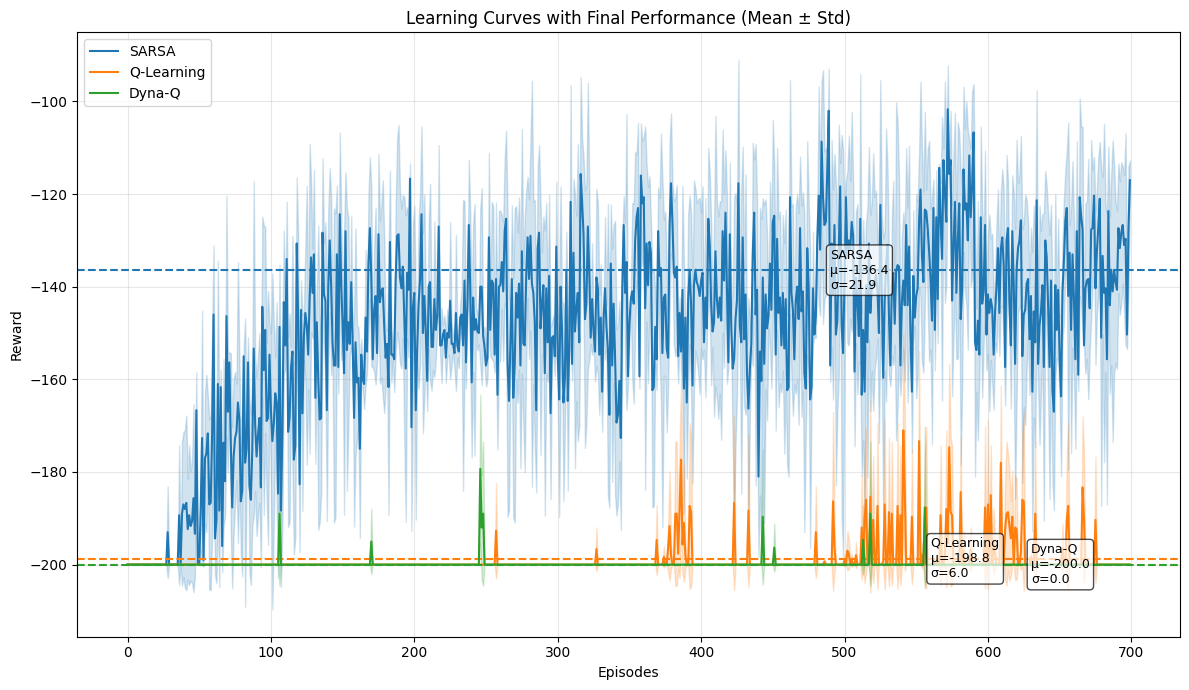

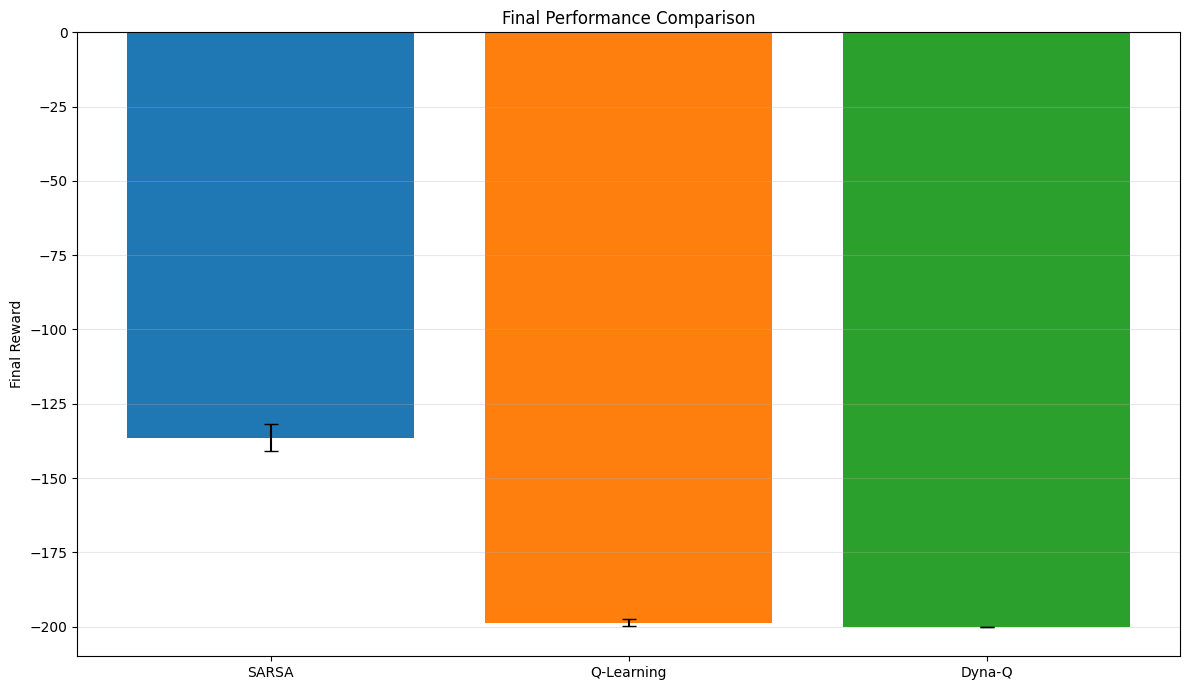

In [24]:
plot_learning_curves(results)
plot_final_performance(results)
